In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

!pip install folium
import folium

from folium.plugins import HeatMap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.1/94.1 kB 10.6 MB/s eta 0:00:00


In [3]:
df = pd.read_csv("/content/drive/MyDrive/US data/US_Accidents_March23.csv")

In [4]:
df.head()

df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

,0
ID,0
Source,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
End_Lat,3402762
End_Lng,3402762
Distance(mi),0


In [5]:
columns_to_drop = [
'ID',
'Description',
'Wind_Chill(F)',
'Precipitation(in)'
]

df.drop(columns=columns_to_drop,inplace=True)

In [6]:
df.dropna(inplace=True)

In [8]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format='ISO8601')

df["End_Time"] = pd.to_datetime(df["End_Time"], format='ISO8601')

In [9]:
df["Hour"] = df["Start_Time"].dt.hour

In [10]:
df["Day"] = df["Start_Time"].dt.day_name()

In [11]:
df["Month"] = df["Start_Time"].dt.month_name()

In [12]:
df["Year"] = df["Start_Time"].dt.year

In [13]:
df["Weekend"] = df["Day"].isin(["Saturday","Sunday"])

In [15]:
df["Duration"] = (
df["End_Time"]-df["Start_Time"]
).dt.total_seconds()/3600

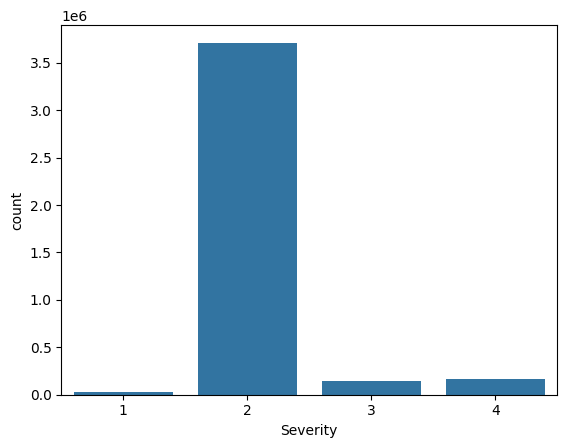

In [17]:
sns.countplot(
data=df,
x="Severity"
)

plt.show()

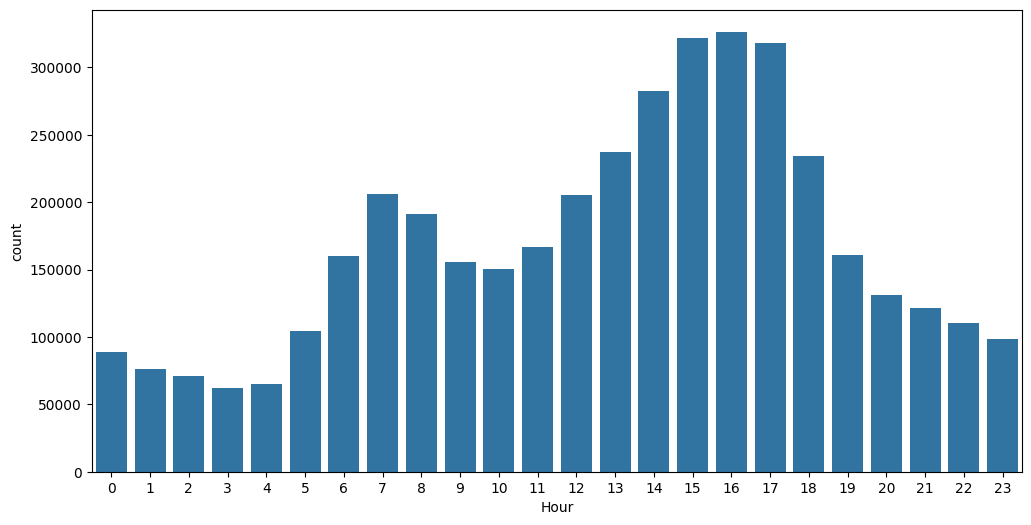

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
data=df,
x="Hour"
)

plt.show()

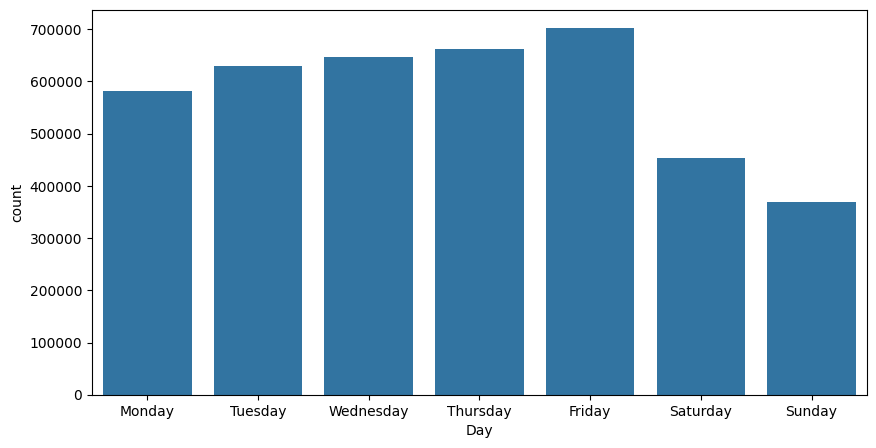

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
data=df,
x="Day",
order=[
"Monday",
"Tuesday",
"Wednesday",
"Thursday",
"Friday",
"Saturday",
"Sunday"
]
)

plt.show()

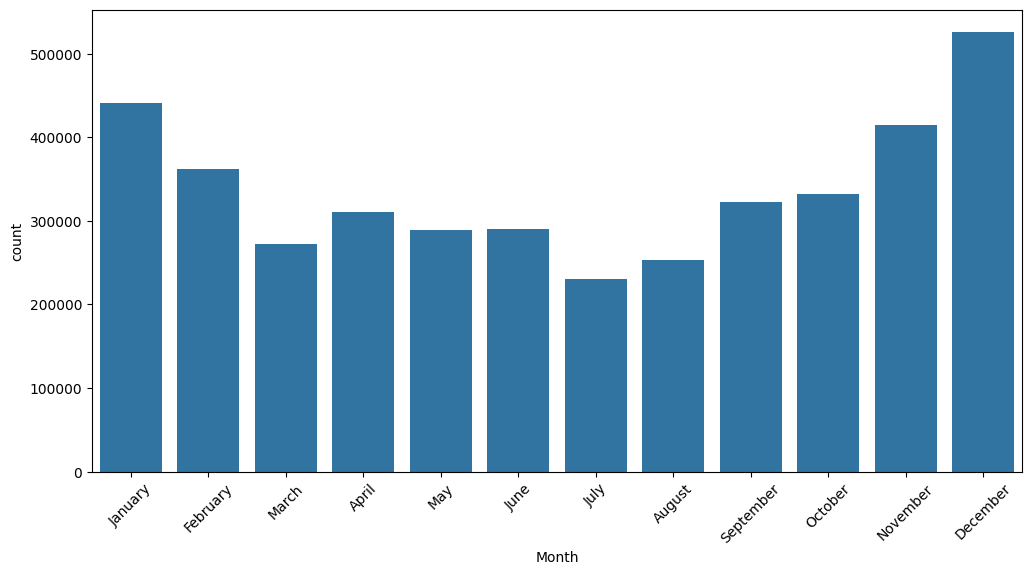

In [20]:
plt.figure(figsize=(12,6))

sns.countplot(
data=df,
x="Month",
order=[
"January","February","March",
"April","May","June",
"July","August","September",
"October","November","December"
]
)

plt.xticks(rotation=45)

plt.show()

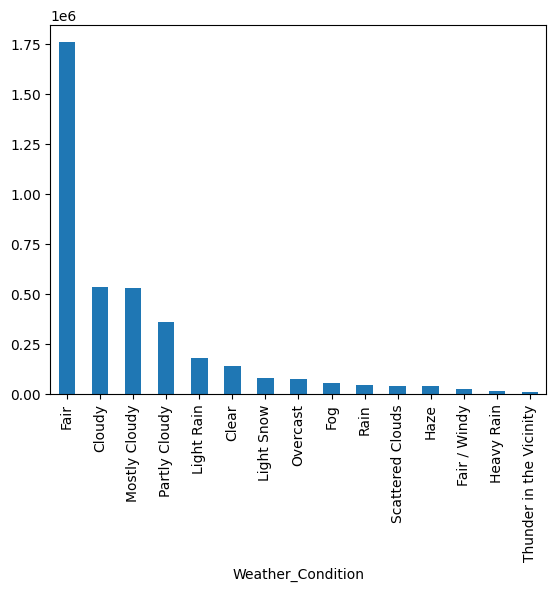

In [21]:
top_weather = df["Weather_Condition"].value_counts().head(15)

top_weather.plot(
kind="bar"
)

plt.show()

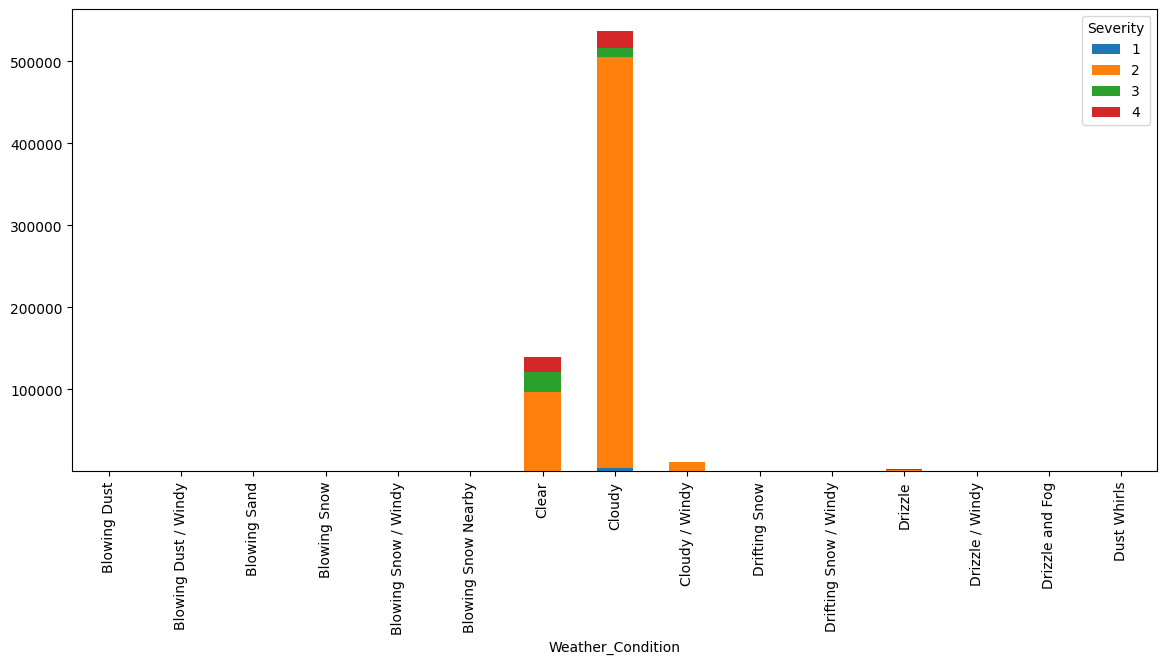

In [22]:
weather = pd.crosstab(
df["Weather_Condition"],
df["Severity"]
)

weather.head(15).plot(
kind="bar",
stacked=True,
figsize=(14,6)
)

plt.show()

In [23]:
road_features = [
"Junction",
"Traffic_Signal",
"Crossing",
"Railway",
"Stop"
]

for feature in road_features:

    print(feature)

    print(df[feature].value_counts())

Junction
Junction
False    3683722
True      361025
Name: count, dtype: int64
Traffic_Signal
Traffic_Signal
False    3673782
True      370965
Name: count, dtype: int64
Crossing
Crossing
False    3673742
True      371005
Name: count, dtype: int64
Railway
Railway
False    4013182
True       31565
Name: count, dtype: int64
Stop
Stop
False    3944994
True       99753
Name: count, dtype: int64


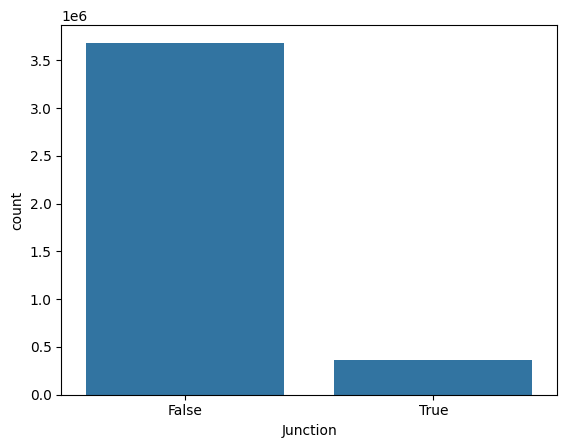

In [24]:
sns.countplot(
data=df,
x="Junction"
)

plt.show()

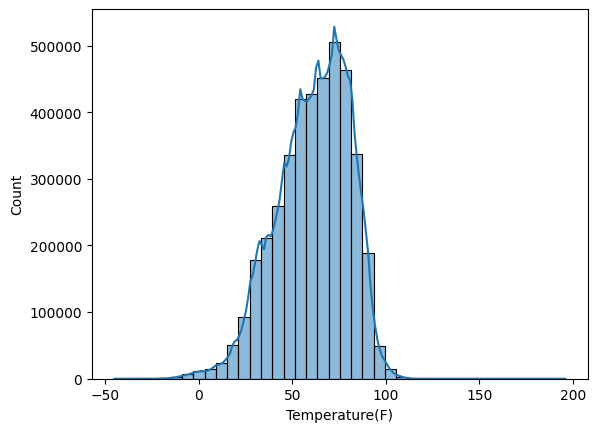

In [25]:
sns.histplot(
df["Temperature(F)"],
bins=40,
kde=True
)

plt.show()

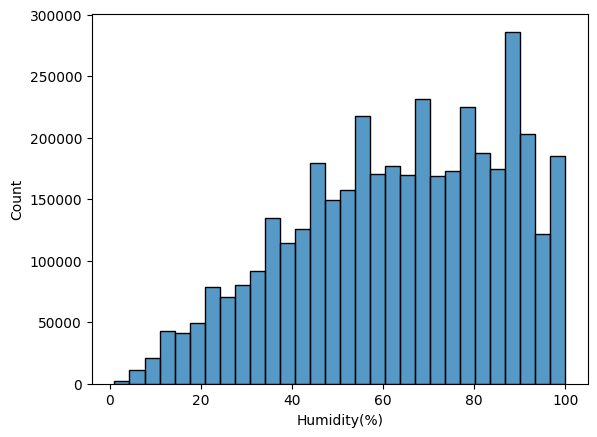

In [26]:
sns.histplot(
df["Humidity(%)"],
bins=30
)

plt.show()

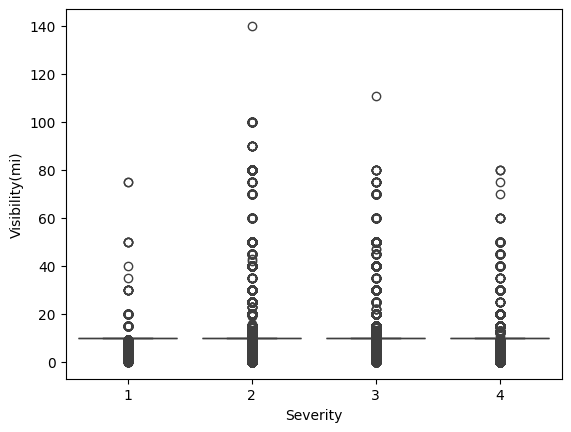

In [27]:
sns.boxplot(
x="Severity",
y="Visibility(mi)",
data=df
)

plt.show()

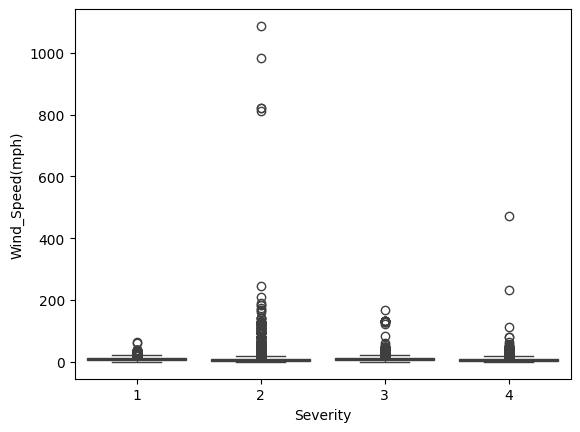

In [28]:
sns.boxplot(
x="Severity",
y="Wind_Speed(mph)",
data=df
)

plt.show()

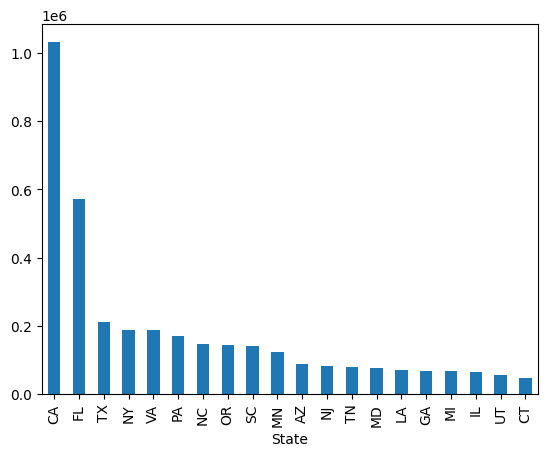

In [29]:
top_states = df["State"].value_counts().head(20)

top_states.plot(
kind="bar"
)

plt.show()

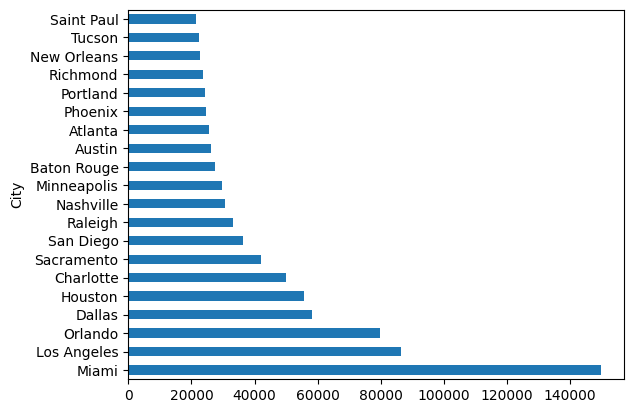

In [30]:
top_city = df["City"].value_counts().head(20)

top_city.plot(
kind="barh"
)

plt.show()

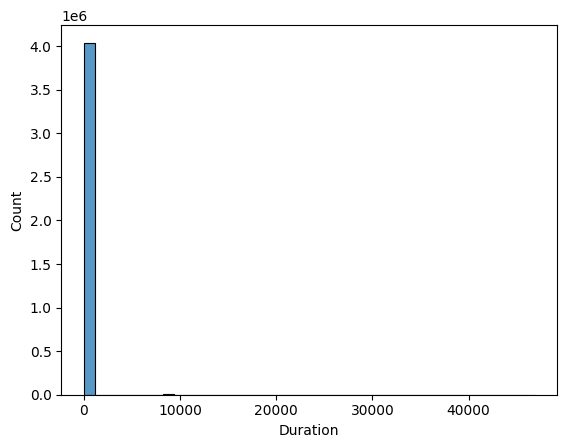

In [31]:
sns.histplot(
df["Duration"],
bins=40
)

plt.show()

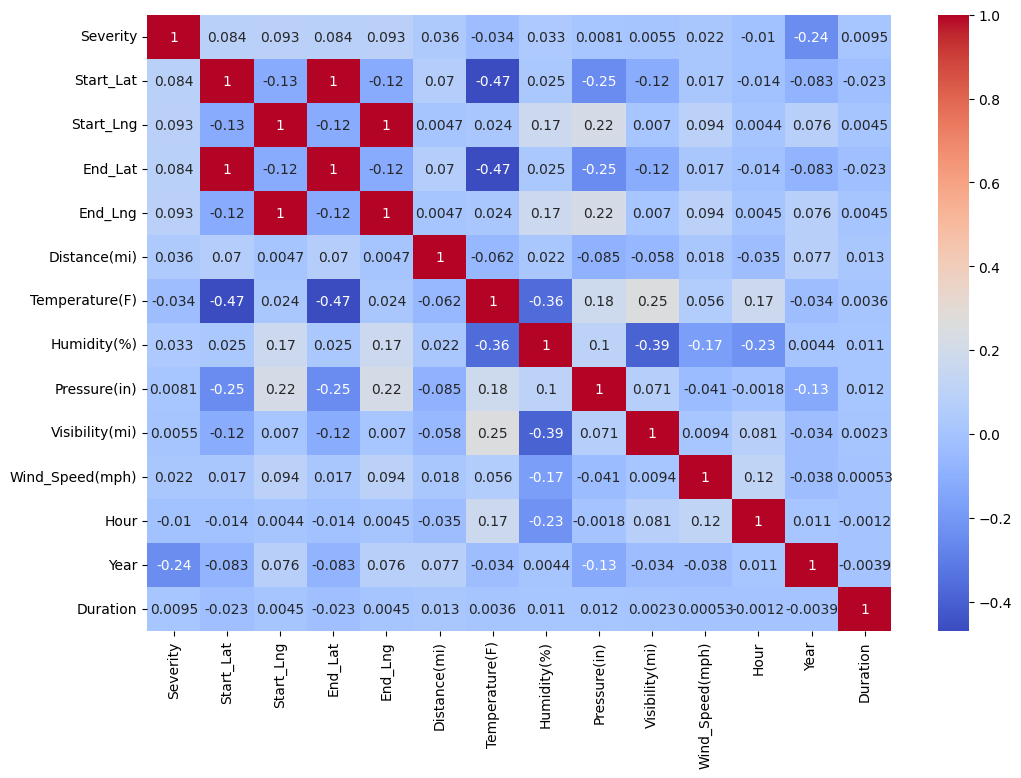

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(
df.select_dtypes(include=np.number).corr(),
annot=True,
cmap="coolwarm"
)

plt.show()

In [33]:
sample = df.sample(10000)

In [34]:
m = folium.Map(
location=[
sample["Start_Lat"].mean(),
sample["Start_Lng"].mean()
],
zoom_start=4
)

In [35]:
HeatMap(
sample[["Start_Lat","Start_Lng"]]
).add_to(m)

m

In [36]:
fig = px.scatter_mapbox(
sample,
lat="Start_Lat",
lon="Start_Lng",
color="Severity",
hover_name="City",
zoom=3,
height=700
)

fig.update_layout(
mapbox_style="open-street-map"
)

fig.show()